In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier

loading the file

In [ ]:
df=pd.read_excel("bankruptcy-prevention.xlsx")

FileNotFoundError: [Errno 2] No such file or directory: 'bankruptcy-prevention.csv'

In [ ]:
df

,industrial_risk; management_risk; financial_flexibility; credibility; competitiveness; operating_risk; class
0,0.5;1;0;0;0;0.5;bankruptcy
1,0;1;0;0;0;1;bankruptcy
2,1;0;0;0;0;1;bankruptcy
3,0.5;0;0;0.5;0;1;bankruptcy
4,1;1;0;0;0;1;bankruptcy
...,...
245,0;1;1;1;1;1;non-bankruptcy
246,1;1;0.5;1;1;0;non-bankruptcy
247,0;1;1;0.5;0.5;0;non-bankruptcy
248,1;0;0.5;1;0.5;0;non-bankruptcy


This line takes the original DataFrame df and selects a specific column. The selected column seems to contain values separated by semicolons. The str.split(';', expand=True) function is then applied to each element in that column. This function splits each element based on the semicolon and expands the result into separate columns.

In [ ]:
# Split the columns using the semicolon
df = df['industrial_risk; management_risk; financial_flexibility; credibility; competitiveness; operating_risk; class'].str.split(';', expand=True)
df

,0,1,2,3,4,5,6
0,0.5,1,0,0,0,0.5,bankruptcy
1,0,1,0,0,0,1,bankruptcy
2,1,0,0,0,0,1,bankruptcy
3,0.5,0,0,0.5,0,1,bankruptcy
4,1,1,0,0,0,1,bankruptcy
...,...,...,...,...,...,...,...
245,0,1,1,1,1,1,non-bankruptcy
246,1,1,0.5,1,1,0,non-bankruptcy
247,0,1,1,0.5,0.5,0,non-bankruptcy
248,1,0,0.5,1,0.5,0,non-bankruptcy


After the split, the columns are labeled with numerical indices (0, 1, 2, ...). This line of code assigns new column names to the DataFrame using the columns attribute. It's creating a more readable and meaningful set of column names for the DataFrame.

In [ ]:
# Rename the columns
df.columns = ['industrial_risk', 'management_risk', 'financial_flexibility', 'credibility', 'competitiveness', 'operating_risk', 'class']
df

,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class
0,0.5,1,0,0,0,0.5,bankruptcy
1,0,1,0,0,0,1,bankruptcy
2,1,0,0,0,0,1,bankruptcy
3,0.5,0,0,0.5,0,1,bankruptcy
4,1,1,0,0,0,1,bankruptcy
...,...,...,...,...,...,...,...
245,0,1,1,1,1,1,non-bankruptcy
246,1,1,0.5,1,1,0,non-bankruptcy
247,0,1,1,0.5,0.5,0,non-bankruptcy
248,1,0,0.5,1,0.5,0,non-bankruptcy


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   industrial_risk        250 non-null    object
 1   management_risk        250 non-null    object
 2   financial_flexibility  250 non-null    object
 3   credibility            250 non-null    object
 4   competitiveness        250 non-null    object
 5   operating_risk         250 non-null    object
 6   class                  250 non-null    object
dtypes: object(7)
memory usage: 13.8+ KB


In [ ]:
df.describe()

,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class
count,250,250,250,250,250,250,250
unique,3,3,3,3,3,3,2
top,1,1,0,0,0,1,non-bankruptcy
freq,89,119,119,94,103,114,143


Missing Values

In [ ]:
null_values=df.isnull()
null_values

,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
245,False,False,False,False,False,False,False
246,False,False,False,False,False,False,False
247,False,False,False,False,False,False,False
248,False,False,False,False,False,False,False


Plotting null values using a bar chart

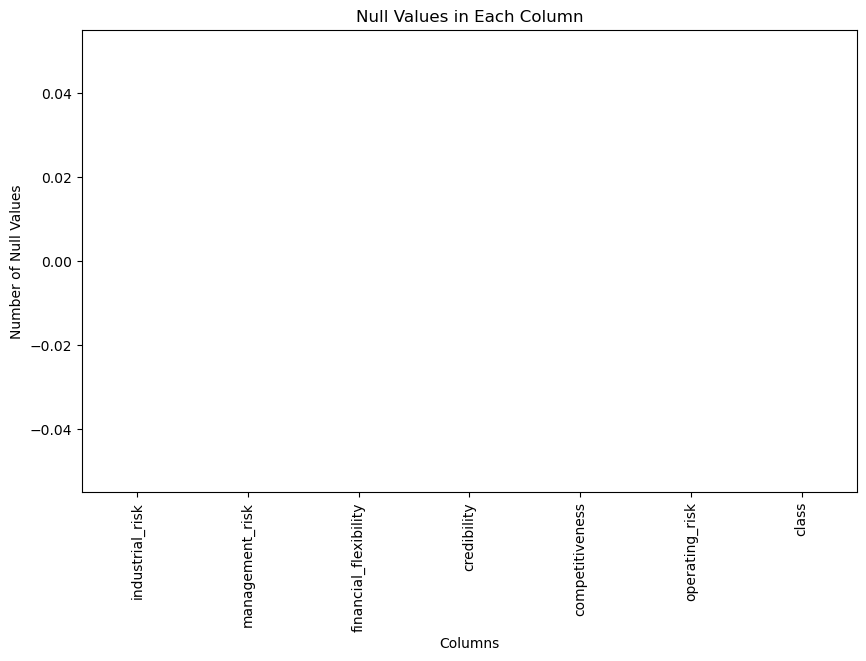

In [ ]:
plt.figure(figsize=(10, 6))
null_values.sum().plot(kind='bar', color='skyblue')
plt.ylabel('Number of Null Values')
plt.xlabel('Columns')
plt.title('Null Values in Each Column')
plt.show()

In [ ]:
#creating one more column in the data frame "class_numeric"
df['class_numeric'] = df['class'].map({'bankruptcy': 0, 'non-bankruptcy': 1})
df

,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class,class_numeric
0,0.5,1,0,0,0,0.5,bankruptcy,0
1,0,1,0,0,0,1,bankruptcy,0
2,1,0,0,0,0,1,bankruptcy,0
3,0.5,0,0,0.5,0,1,bankruptcy,0
4,1,1,0,0,0,1,bankruptcy,0
...,...,...,...,...,...,...,...,...
245,0,1,1,1,1,1,non-bankruptcy,1
246,1,1,0.5,1,1,0,non-bankruptcy,1
247,0,1,1,0.5,0.5,0,non-bankruptcy,1
248,1,0,0.5,1,0.5,0,non-bankruptcy,1


In [ ]:
#copy the dataframe df to "train_df"
train_df=df.copy()

In [ ]:
#dropping the column "class"
train_df = train_df.drop('class', axis=1)

In [ ]:
train_df# we got  the dataframe for modeling

,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class_numeric
0,0.5,1,0,0,0,0.5,0
1,0,1,0,0,0,1,0
2,1,0,0,0,0,1,0
3,0.5,0,0,0.5,0,1,0
4,1,1,0,0,0,1,0
...,...,...,...,...,...,...,...
245,0,1,1,1,1,1,1
246,1,1,0.5,1,1,0,1
247,0,1,1,0.5,0.5,0,1
248,1,0,0.5,1,0.5,0,1


In [ ]:
train_df.dtypes

industrial_risk          object
management_risk          object
financial_flexibility    object
credibility              object
competitiveness          object
operating_risk           object
class_numeric             int64
dtype: object

In [ ]:
#changing the data types of the columns to "float"
train_df['industrial_risk'] = train_df['industrial_risk'].astype(float)
train_df['management_risk'] = train_df['management_risk'].astype(float)
train_df['financial_flexibility'] = train_df['financial_flexibility'].astype(float)
train_df['credibility'] = train_df['credibility'].astype(float)
train_df['competitiveness'] = train_df['competitiveness'].astype(float)
train_df['operating_risk'] = train_df['operating_risk'].astype(float)
train_df['class_numeric'] = train_df['class_numeric'].astype(float)

# Check the data types again
print(train_df.dtypes)

industrial_risk          float64
management_risk          float64
financial_flexibility    float64
credibility              float64
competitiveness          float64
operating_risk           float64
class_numeric            float64
dtype: object


# Exploratory Data Analysis(EDA)

class(target_variable)

In [ ]:
class_counts = df['class'].value_counts()
class_counts

class
non-bankruptcy    143
bankruptcy        107
Name: count, dtype: int64

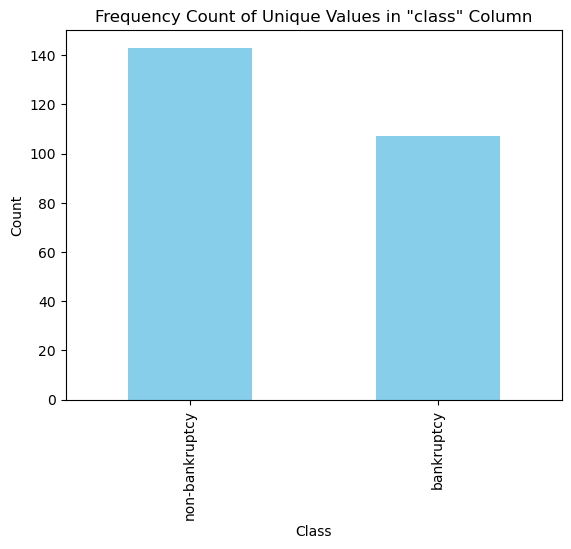

In [ ]:
# Plotting
class_counts.plot(kind='bar', color='skyblue')
plt.title('Frequency Count of Unique Values in "class" Column')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [ ]:
#dropping the column class_numeric"
df = df.drop('class_numeric', axis=1)

In [ ]:
df #original given dataframe

,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class
0,0.5,1,0,0,0,0.5,bankruptcy
1,0,1,0,0,0,1,bankruptcy
2,1,0,0,0,0,1,bankruptcy
3,0.5,0,0,0.5,0,1,bankruptcy
4,1,1,0,0,0,1,bankruptcy
...,...,...,...,...,...,...,...
245,0,1,1,1,1,1,non-bankruptcy
246,1,1,0.5,1,1,0,non-bankruptcy
247,0,1,1,0.5,0.5,0,non-bankruptcy
248,1,0,0.5,1,0.5,0,non-bankruptcy


industrial_risk

Industrial Risk:

Refers to the potential hazards and uncertainties associated with the specific industry in which a business operates.
Examples include technological changes, regulatory developments, and market fluctuations that can impact the industry.

In [ ]:
#changing the data type of industrial_risk
df['industrial_risk'] = pd.to_numeric(df['industrial_risk'], errors='coerce').fillna(0).astype(float)

In [ ]:
frequency_count = df['industrial_risk'].value_counts()
frequency_count

industrial_risk
1.0    89
0.5    81
0.0    80
Name: count, dtype: int64

In [ ]:
df['industrial_risk'] = df['industrial_risk'].map({0: 'Low risk', 0.5: 'Medium risk', 1: 'High risk'})

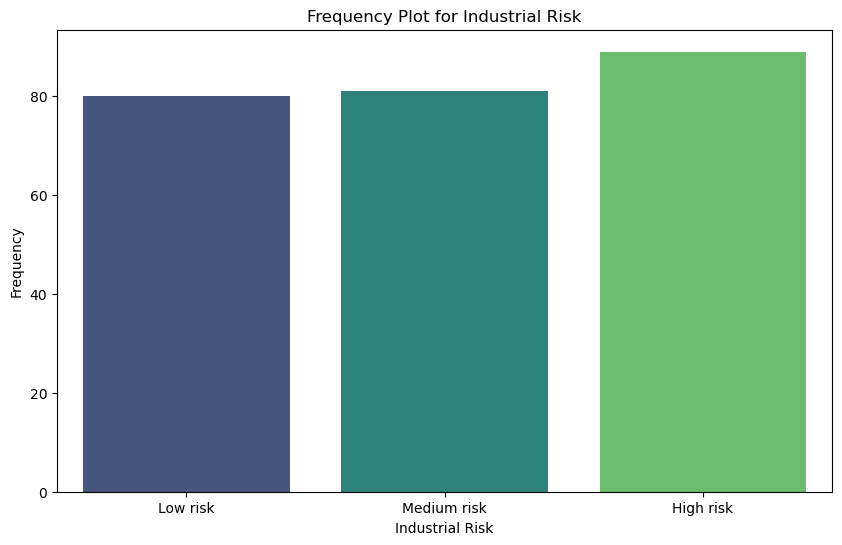

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='industrial_risk', data=df, palette='viridis', order=['Low risk', 'Medium risk', 'High risk'])
plt.xlabel('Industrial Risk')
plt.ylabel('Frequency')
plt.title('Frequency Plot for Industrial Risk')
plt.show()

In [ ]:
class_industrial_counts = df.groupby(['class', 'industrial_risk']).size().unstack(fill_value=0)
class_industrial_counts

industrial_risk,High risk,Low risk,Medium risk
class,,,
bankruptcy,53,26,28
non-bankruptcy,36,54,53


count: This column shows the number of non-null values in each group. For 'bankruptcy,' there are 107 non-null values, and for 'non-bankruptcy,' there are 143 non-null values.

unique: This column represents the number of unique values in each group. In both 'bankruptcy' and 'non-bankruptcy,' there are 3 unique values.

top: This column shows the most frequently occurring value in each group. For 'bankruptcy,' the most common value in the 'industrial_risk' column is '1,' and for 'non-bankruptcy,' the most common value is '0.'

freq: This column displays the frequency of the most common value. For 'bankruptcy,' '1' occurs 53 times, and for 'non-bankruptcy,' '0' occurs 54 times.

bankruptacy of industry_risk

In [ ]:
bankruptcy_data = df[df['class'] == 'bankruptcy']
bankruptcy_data

,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class
0,Medium risk,1,0,0,0,0.5,bankruptcy
1,Low risk,1,0,0,0,1,bankruptcy
2,High risk,0,0,0,0,1,bankruptcy
3,Medium risk,0,0,0.5,0,1,bankruptcy
4,High risk,1,0,0,0,1,bankruptcy
...,...,...,...,...,...,...,...
102,High risk,1,0.5,0,0,1,bankruptcy
103,Low risk,1,0,0,0,1,bankruptcy
104,Medium risk,1,0,0,0,1,bankruptcy
105,High risk,1,0,0,0,1,bankruptcy


In [ ]:
bankruptcy_counts = df[df['class'] == 'bankruptcy']['industrial_risk'].value_counts()
bankruptcy_counts

industrial_risk
High risk      53
Medium risk    28
Low risk       26
Name: count, dtype: int64

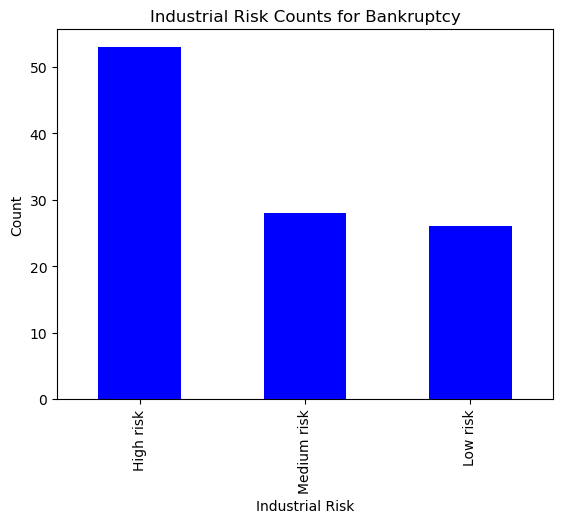

In [ ]:
bankruptcy_counts.plot(kind='bar', color='blue')
plt.title('Industrial Risk Counts for Bankruptcy')
plt.xlabel('Industrial Risk')
plt.ylabel('Count')
plt.show()

non-bankruptcy of industry_risk

In [ ]:
non_bankruptcy_data = df[df['class'] == 'non-bankruptcy']
non_bankruptcy_data

,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class
107,Low risk,0,0.5,0.5,0.5,0,non-bankruptcy
108,High risk,1,0.5,0.5,0.5,1,non-bankruptcy
109,Medium risk,0.5,0.5,0.5,0.5,0.5,non-bankruptcy
110,Low risk,0,1,1,1,0,non-bankruptcy
111,High risk,1,1,1,1,1,non-bankruptcy
...,...,...,...,...,...,...,...
245,Low risk,1,1,1,1,1,non-bankruptcy
246,High risk,1,0.5,1,1,0,non-bankruptcy
247,Low risk,1,1,0.5,0.5,0,non-bankruptcy
248,High risk,0,0.5,1,0.5,0,non-bankruptcy


In [ ]:
non_bankruptcy_counts = df[df['class'] == 'non-bankruptcy']['industrial_risk'].value_counts()
non_bankruptcy_counts

industrial_risk
Low risk       54
Medium risk    53
High risk      36
Name: count, dtype: int64

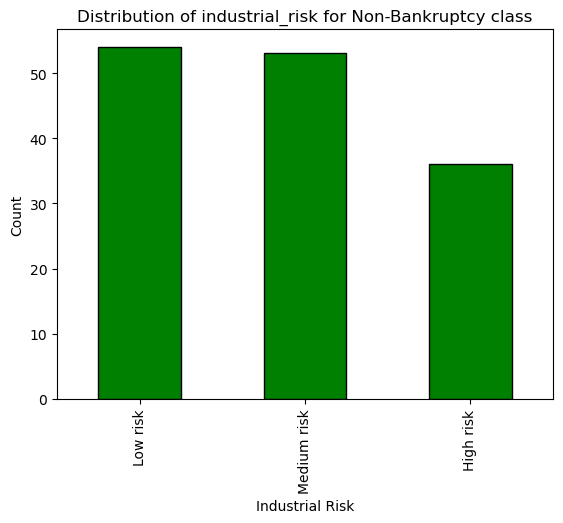

In [ ]:
non_bankruptcy_counts.plot(kind='bar', color='green', edgecolor='black')
plt.title('Distribution of industrial_risk for Non-Bankruptcy class')
plt.xlabel('Industrial Risk')
plt.ylabel('Count')
plt.show()

Management Risk:

Involves the potential negative impact of managerial decisions or actions on the overall performance of a business.
It includes risks related to leadership effectiveness, decision-making processes, and the ability of the management team to respond to challenges.

In [ ]:
#changing the data type of industrial_risk
df['management_risk'] = pd.to_numeric(df['management_risk'], errors='coerce').fillna(0).astype(float)

In [ ]:
#value_counts for management risk
frequency_count = df['management_risk'].value_counts()
frequency_count # below u can see there are 3 unique value holding values of bankruptcy and non bankruptcy

management_risk
1.0    119
0.5     69
0.0     62
Name: count, dtype: int64

In [ ]:
df['management_risk'] = df['management_risk'].map({0: 'Low risk', 0.5: 'Medium risk', 1: 'High risk'})

In [ ]:
df

,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class
0,Medium risk,High risk,0,0,0,0.5,bankruptcy
1,Low risk,High risk,0,0,0,1,bankruptcy
2,High risk,Low risk,0,0,0,1,bankruptcy
3,Medium risk,Low risk,0,0.5,0,1,bankruptcy
4,High risk,High risk,0,0,0,1,bankruptcy
...,...,...,...,...,...,...,...
245,Low risk,High risk,1,1,1,1,non-bankruptcy
246,High risk,High risk,0.5,1,1,0,non-bankruptcy
247,Low risk,High risk,1,0.5,0.5,0,non-bankruptcy
248,High risk,Low risk,0.5,1,0.5,0,non-bankruptcy


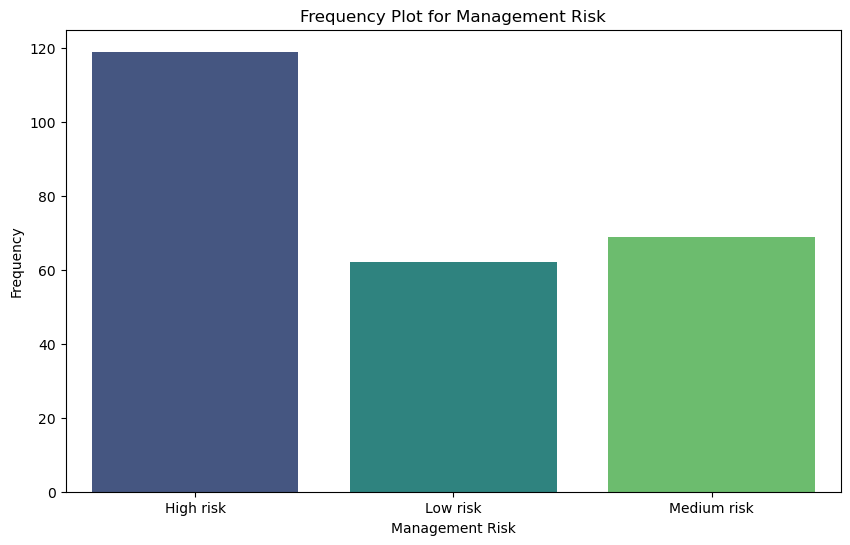

In [ ]:
# Plotting count plot for management_risk
plt.figure(figsize=(10, 6))
sns.countplot(x='management_risk', data=df, palette='viridis')
plt.xlabel('Management Risk')
plt.ylabel('Frequency')
plt.title('Frequency Plot for Management Risk')
plt.show()

In [ ]:
class_managerial_counts = df.groupby(['class', 'management_risk']).size().unstack(fill_value=0)
class_managerial_counts

management_risk,High risk,Low risk,Medium risk
class,,,
bankruptcy,73,11,23
non-bankruptcy,46,51,46


bankruptcy of management_risk

In [ ]:
bankruptcy_counts = df[df['class'] == 'bankruptcy']['management_risk'].value_counts()
bankruptcy_counts

management_risk
High risk      73
Medium risk    23
Low risk       11
Name: count, dtype: int64

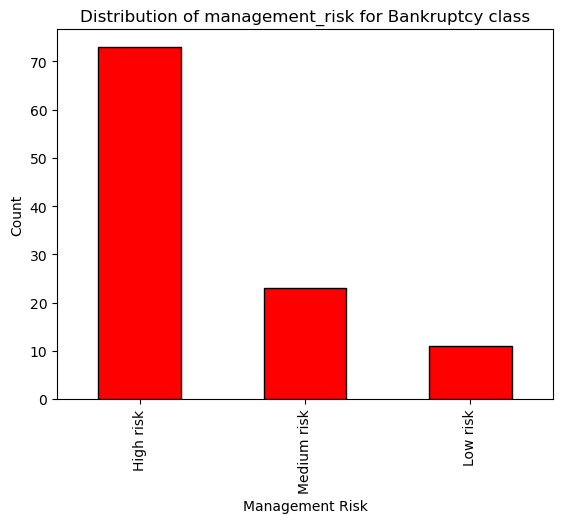

In [ ]:
bankruptcy_counts.plot(kind='bar', color='red', edgecolor='black')
plt.title('Distribution of management_risk for Bankruptcy class')
plt.xlabel('Management Risk')
plt.ylabel('Count')
plt.show()

non-bankruptcy of management_risk

In [ ]:
non_bankruptcy_counts = df[df['class'] == 'non-bankruptcy']['management_risk'].value_counts()
non_bankruptcy_counts

management_risk
Low risk       51
High risk      46
Medium risk    46
Name: count, dtype: int64

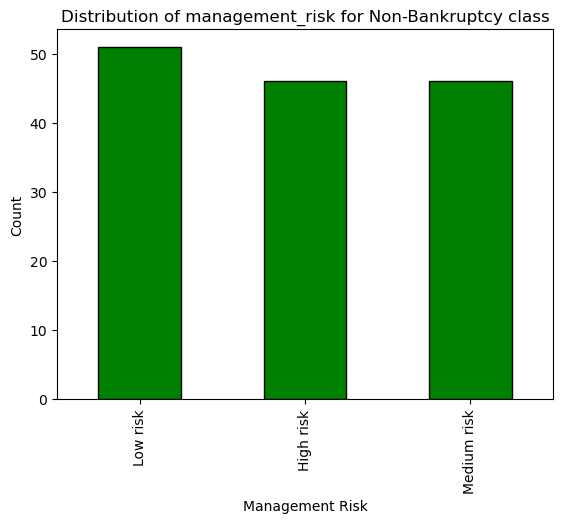

In [ ]:
non_bankruptcy_counts.plot(kind='bar', color='green', edgecolor='black')
plt.title('Distribution of management_risk for Non-Bankruptcy class')
plt.xlabel('Management Risk')
plt.ylabel('Count')
plt.show()

Financial Flexibility:

Represents the ability of a company to adapt and respond to financial challenges or opportunities.
A financially flexible company can efficiently manage its capital structure, access funding when needed, and make strategic financial decisions.

In [ ]:
#changing the data type of Financial Flexibility:
df['financial_flexibility'] = pd.to_numeric(df['financial_flexibility'], errors='coerce').fillna(0).astype(float)

In [ ]:
frequency_count = df['financial_flexibility'].value_counts()
frequency_count

financial_flexibility
0.0    119
0.5     74
1.0     57
Name: count, dtype: int64

In [ ]:
# Mapping values for better understanding
df['financial_flexibility'] = df['financial_flexibility'].map({0: 'Low flexibility', 0.5: 'Medium flexibility', 1: 'High flexibility'})

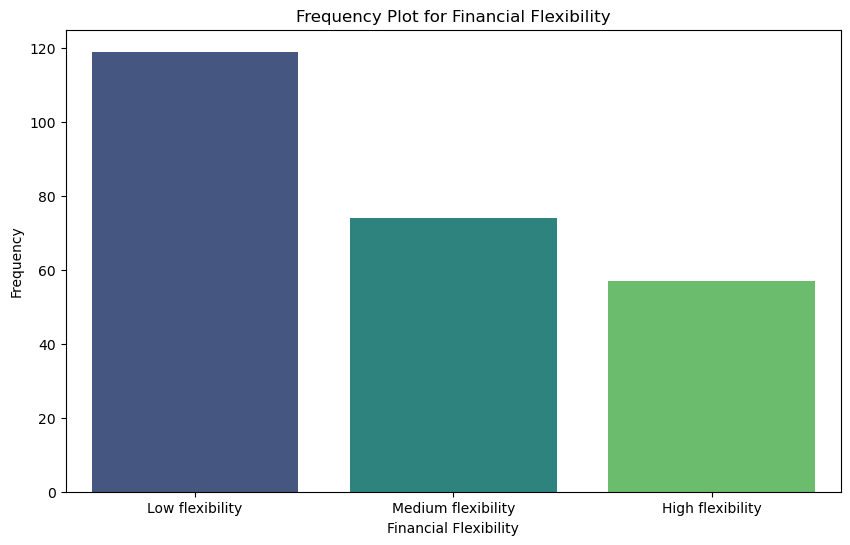

In [ ]:
# Plotting count plot for financial_flexibility
plt.figure(figsize=(10, 6))
sns.countplot(x='financial_flexibility', data=df, palette='viridis', order=['Low flexibility', 'Medium flexibility', 'High flexibility'])
plt.xlabel('Financial Flexibility')
plt.ylabel('Frequency')
plt.title('Frequency Plot for Financial Flexibility')
plt.show()

In [ ]:
class_financial_flexibility_counts = df.groupby(['class', 'financial_flexibility']).size().unstack(fill_value=0)
class_financial_flexibility_counts

financial_flexibility,High flexibility,Low flexibility,Medium flexibility
class,,,
bankruptcy,1,102,4
non-bankruptcy,56,17,70


bankruptcy for financial_flexibility

In [ ]:
bankruptcy_counts = df[df['class'] == 'bankruptcy']['financial_flexibility'].value_counts()
bankruptcy_counts

financial_flexibility
Low flexibility       102
Medium flexibility      4
High flexibility        1
Name: count, dtype: int64

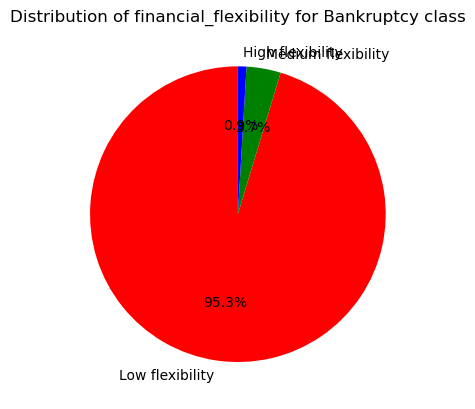

In [ ]:
plt.pie(bankruptcy_counts, labels=bankruptcy_counts.index, autopct='%1.1f%%', startangle=90, colors=['red', 'green', 'blue'])
plt.title('Distribution of financial_flexibility for Bankruptcy class')
plt.show()

non-bankruptcy for financial_flexibility

In [ ]:
non_bankruptcy_counts = df[df['class'] == 'non-bankruptcy']['financial_flexibility'].value_counts()
non_bankruptcy_counts

financial_flexibility
Medium flexibility    70
High flexibility      56
Low flexibility       17
Name: count, dtype: int64

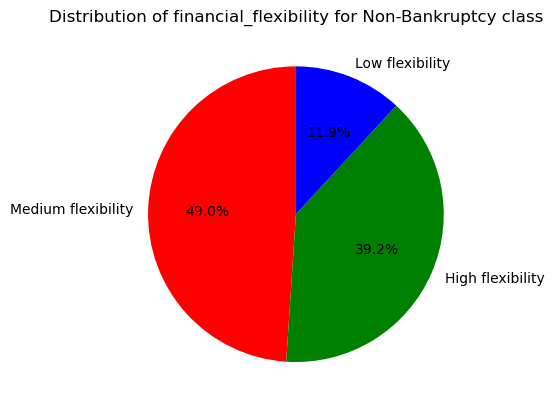

In [ ]:
plt.pie(non_bankruptcy_counts, labels=non_bankruptcy_counts.index, autopct='%1.1f%%', startangle=90, colors=['red', 'green', 'blue'])
plt.title('Distribution of financial_flexibility for Non-Bankruptcy class')
plt.show()

Credibility:

Relates to the trustworthiness and reputation of a business, both among its stakeholders and in the market.
Credibility is essential for building and maintaining relationships with customers, investors, employees, and other key stakeholders.

In [ ]:
#changing the data type of Credibility:
df['credibility'] = pd.to_numeric(df['credibility'], errors='coerce').fillna(0).astype(float)

In [ ]:
frequency_count = df['credibility'].value_counts()
frequency_count

credibility
0.0    94
1.0    79
0.5    77
Name: count, dtype: int64

In [ ]:
# Mapping values for better understanding
df['credibility'] = df['credibility'].map({0: 'Low credibility', 0.5: 'Medium credibility', 1: 'High credibility'})

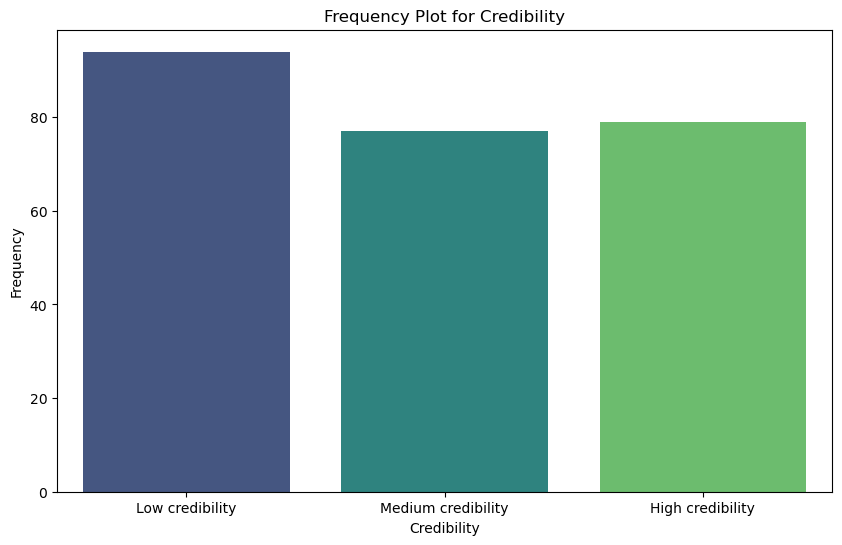

In [ ]:
# Plotting count plot for credibility
plt.figure(figsize=(10, 6))
sns.countplot(x='credibility', data=df, palette='viridis', order=['Low credibility', 'Medium credibility', 'High credibility'])
plt.xlabel('Credibility')
plt.ylabel('Frequency')
plt.title('Frequency Plot for Credibility')
plt.show()

In [ ]:
class_credibility_counts = df.groupby(['class', 'credibility']).size().unstack(fill_value=0)
class_credibility_counts

credibility,High credibility,Low credibility,Medium credibility
class,,,
bankruptcy,3,87,17
non-bankruptcy,76,7,60


bankruptcy for credibility

In [ ]:
bankruptcy_counts = df[df['class'] == 'bankruptcy']['credibility'].value_counts()
bankruptcy_counts

credibility
Low credibility       87
Medium credibility    17
High credibility       3
Name: count, dtype: int64

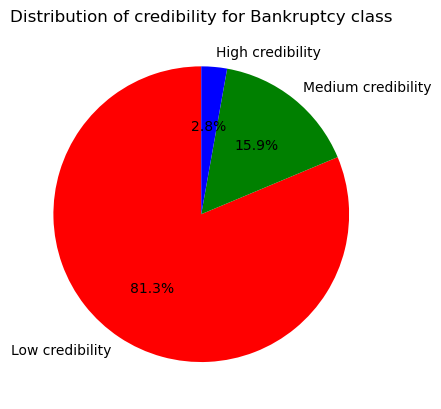

In [ ]:
plt.pie(bankruptcy_counts, labels=bankruptcy_counts.index, autopct='%1.1f%%', startangle=90, colors=['red', 'green', 'blue'])
plt.title('Distribution of credibility for Bankruptcy class')
plt.show()

non-bankruptcy for credibility

In [ ]:
non_bankruptcy_counts = df[df['class'] == 'non-bankruptcy']['credibility'].value_counts()
non_bankruptcy_counts

credibility
High credibility      76
Medium credibility    60
Low credibility        7
Name: count, dtype: int64

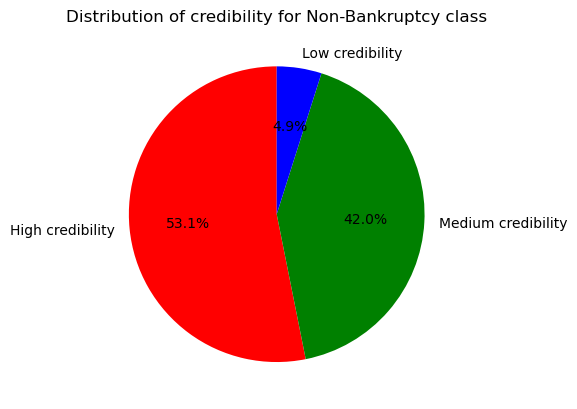

In [ ]:
plt.pie(non_bankruptcy_counts, labels=non_bankruptcy_counts.index, autopct='%1.1f%%', startangle=90, colors=['red', 'green', 'blue'])
plt.title('Distribution of credibility for Non-Bankruptcy class')
plt.show()

Competitiveness:

Refers to a company's ability to maintain and enhance its market position relative to its competitors.
Competitive factors include pricing, quality of products or services, innovation, marketing strategies, and overall market presence.

In [ ]:
#changing the data type of Competitiveness:
df['competitiveness'] = pd.to_numeric(df['competitiveness'], errors='coerce').fillna(0).astype(float)

In [ ]:
frequency_count = df['competitiveness'].value_counts()
frequency_count

competitiveness
0.0    103
1.0     91
0.5     56
Name: count, dtype: int64

In [ ]:
# Mapping values for better understanding
df['competitiveness'] = df['competitiveness'].map({0: 'Low competitiveness', 0.5: 'Medium competitiveness', 1: 'High competitiveness'})

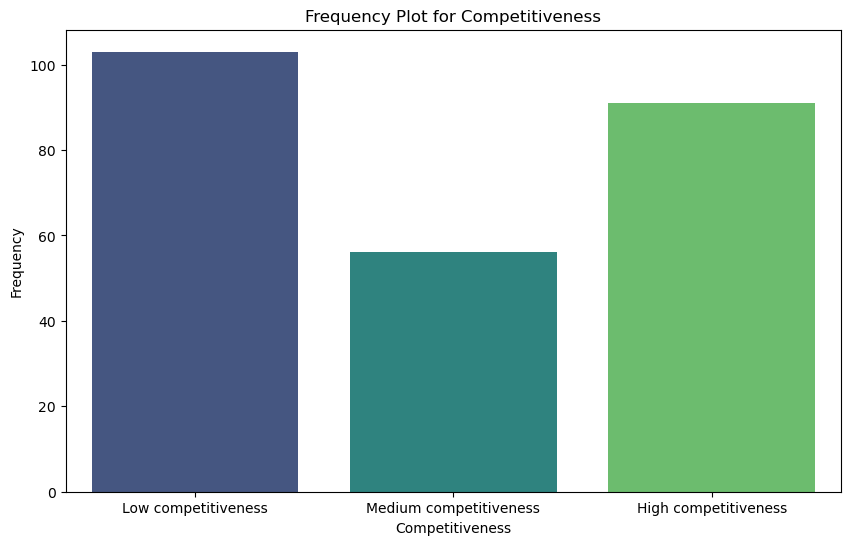

In [ ]:
# Plotting count plot for competitiveness
plt.figure(figsize=(10, 6))
sns.countplot(x='competitiveness', data=df, palette='viridis', order=['Low competitiveness', 'Medium competitiveness', 'High competitiveness'])
plt.xlabel('Competitiveness')
plt.ylabel('Frequency')
plt.title('Frequency Plot for Competitiveness')
plt.show()

In [ ]:
class_competitiveness_counts = df.groupby(['class', 'competitiveness']).size().unstack(fill_value=0)
class_competitiveness_counts

competitiveness,High competitiveness,Low competitiveness,Medium competitiveness
class,,,
bankruptcy,0,103,4
non-bankruptcy,91,0,52


bankruptcy for competitiveness

In [ ]:
bankruptcy_counts = df[df['class'] == 'bankruptcy']['competitiveness'].value_counts()
bankruptcy_counts

competitiveness
Low competitiveness       103
Medium competitiveness      4
Name: count, dtype: int64

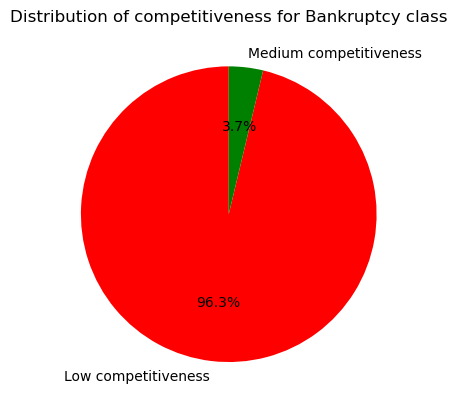

In [ ]:
plt.pie(bankruptcy_counts, labels=bankruptcy_counts.index, autopct='%1.1f%%', startangle=90, colors=['red', 'green', 'blue'])
plt.title('Distribution of competitiveness for Bankruptcy class')
plt.show()

non-bankruptcy for competitiveness

In [ ]:
non_bankruptcy_counts = df[df['class'] == 'non-bankruptcy']['competitiveness'].value_counts()
non_bankruptcy_counts

competitiveness
High competitiveness      91
Medium competitiveness    52
Name: count, dtype: int64

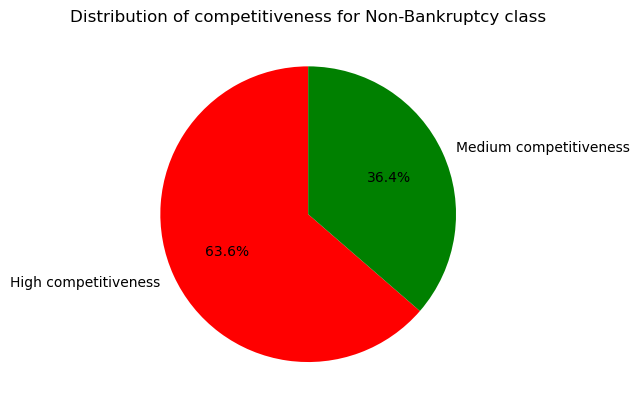

In [ ]:
plt.pie(non_bankruptcy_counts, labels=non_bankruptcy_counts.index, autopct='%1.1f%%', startangle=90, colors=['red', 'green', 'blue'])
plt.title('Distribution of competitiveness for Non-Bankruptcy class')
plt.show()

Operating Risk:

Involves the potential negative impact of day-to-day operational activities on the business.
This includes risks associated with supply chain disruptions, production issues, technology failures, and other operational challenges.

In [ ]:
#changing the data type of Operating Risk:
df['operating_risk'] = pd.to_numeric(df['operating_risk'], errors='coerce').fillna(0).astype(float)

In [ ]:
frequency_count = df['operating_risk'].value_counts()
frequency_count

operating_risk
1.0    114
0.0     79
0.5     57
Name: count, dtype: int64

In [ ]:
# Mapping values for better understanding
df['operating_risk'] = df['operating_risk'].map({0: 'Low risk', 0.5: 'Medium risk', 1: 'High risk'})


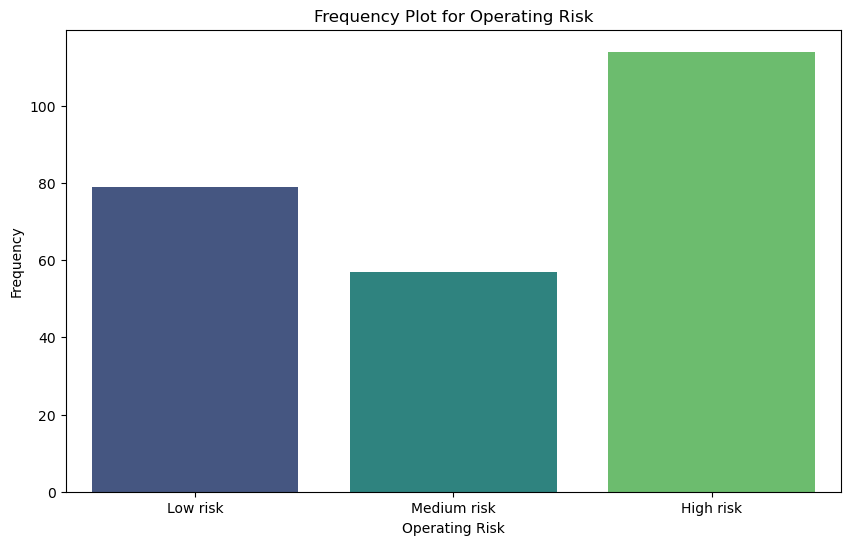

In [ ]:
# Plotting count plot for operating_risk
plt.figure(figsize=(10, 6))
sns.countplot(x='operating_risk', data=df, palette='viridis', order=['Low risk', 'Medium risk', 'High risk'])
plt.xlabel('Operating Risk')
plt.ylabel('Frequency')
plt.title('Frequency Plot for Operating Risk')
plt.show()

In [ ]:
class_operating_counts = df.groupby(['class', 'operating_risk']).size().unstack(fill_value=0)
class_operating_counts

operating_risk,High risk,Low risk,Medium risk
class,,,
bankruptcy,64,19,24
non-bankruptcy,50,60,33


bankruptcy for operating_risk

In [ ]:
bankruptcy_counts = df[df['class'] == 'bankruptcy']['operating_risk'].value_counts()
bankruptcy_counts

operating_risk
High risk      64
Medium risk    24
Low risk       19
Name: count, dtype: int64

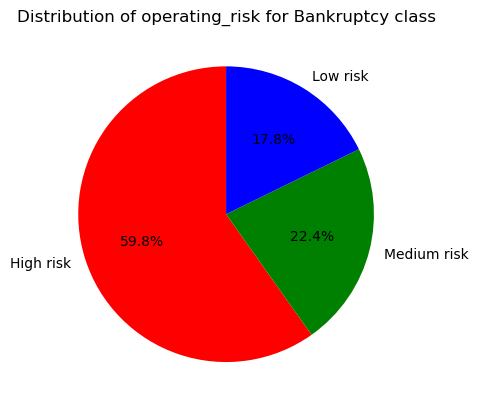

In [ ]:
plt.pie(bankruptcy_counts, labels=bankruptcy_counts.index, autopct='%1.1f%%', startangle=90, colors=['red', 'green', 'blue'])
plt.title('Distribution of operating_risk for Bankruptcy class')
plt.show()

non-bankruptcy for operating_risk

In [ ]:
non_bankruptcy_counts = df[df['class'] == 'non-bankruptcy']['operating_risk'].value_counts()
non_bankruptcy_counts

operating_risk
Low risk       60
High risk      50
Medium risk    33
Name: count, dtype: int64

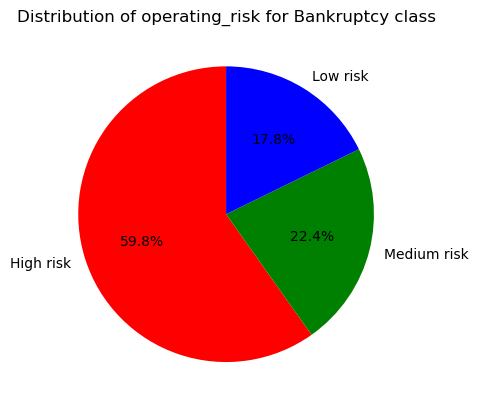

In [ ]:
plt.pie(bankruptcy_counts, labels=bankruptcy_counts.index, autopct='%1.1f%%', startangle=90, colors=['red', 'green', 'blue'])
plt.title('Distribution of operating_risk for Bankruptcy class')
plt.show()

outliers

In [ ]:
numerical_columns = train_df.columns[:-1]  
train_df_numerical = train_df[numerical_columns]

In [ ]:
train_df_numerical = train_df_numerical.apply(pd.to_numeric, errors='coerce')

In [ ]:
train_df_numerical

,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk
0,0.5,1.0,0.0,0.0,0.0,0.5
1,0.0,1.0,0.0,0.0,0.0,1.0
2,1.0,0.0,0.0,0.0,0.0,1.0
3,0.5,0.0,0.0,0.5,0.0,1.0
4,1.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...
245,0.0,1.0,1.0,1.0,1.0,1.0
246,1.0,1.0,0.5,1.0,1.0,0.0
247,0.0,1.0,1.0,0.5,0.5,0.0
248,1.0,0.0,0.5,1.0,0.5,0.0


In [ ]:
z_scores = zscore(train_df_numerical)

In [ ]:
train_df_zscores = pd.DataFrame(z_scores, columns=numerical_columns)

 threshold value:


the threshold value helps define what is considered "normal" or typical for the data, and anything significantly different from that is marked as an outlier. Adjusting the threshold can impact the sensitivity of outlier detection, so it's often chosen based on the characteristics of the data and the goals of the analysis.

In [ ]:
threshold = 3
outliers = (train_df_zscores > threshold) | (train_df_zscores < -threshold)
outliers_rows = train_df[outliers.any(axis=1)]

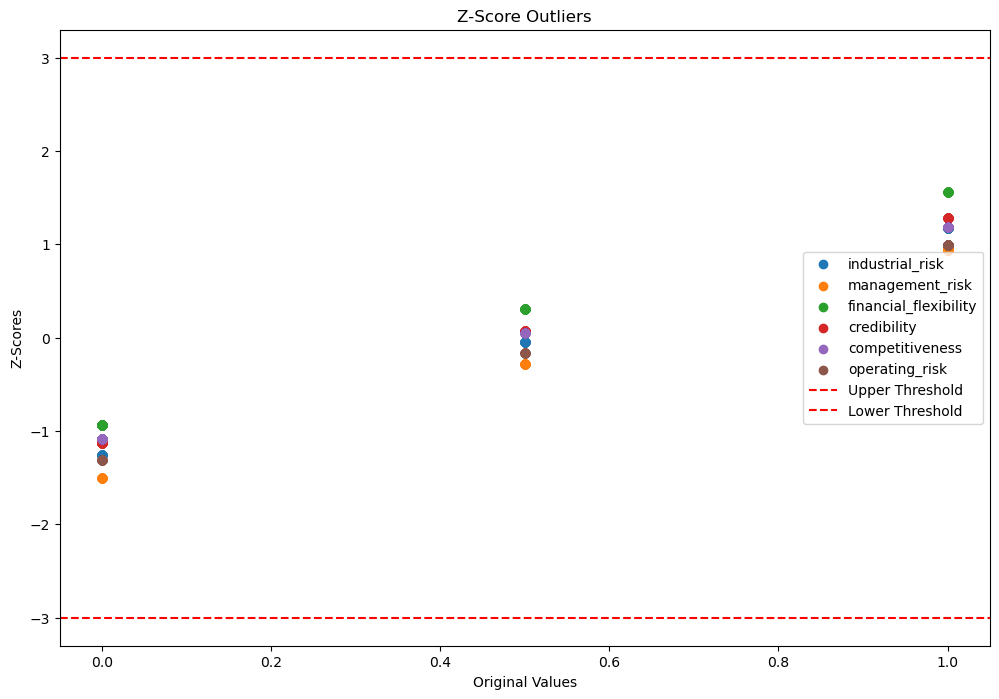

In [ ]:
plt.figure(figsize=(12, 8))
for column in numerical_columns:
    plt.scatter(train_df_numerical[column], train_df_zscores[column], label=column)

plt.axhline(y=threshold, color='r', linestyle='--', label='Upper Threshold')
plt.axhline(y=-threshold, color='r', linestyle='--', label='Lower Threshold')
plt.title('Z-Score Outliers')
plt.xlabel('Original Values')
plt.ylabel('Z-Scores')
plt.legend()
plt.show()

In the scatter plot, each point represents a data point, and the x-axis shows the original values, while the y-axis shows the Z-scores. The red dashed lines represent the upper and lower Z-score thresholds for identifying outliers.

# Data Visualization

C:\Users\kkoll\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


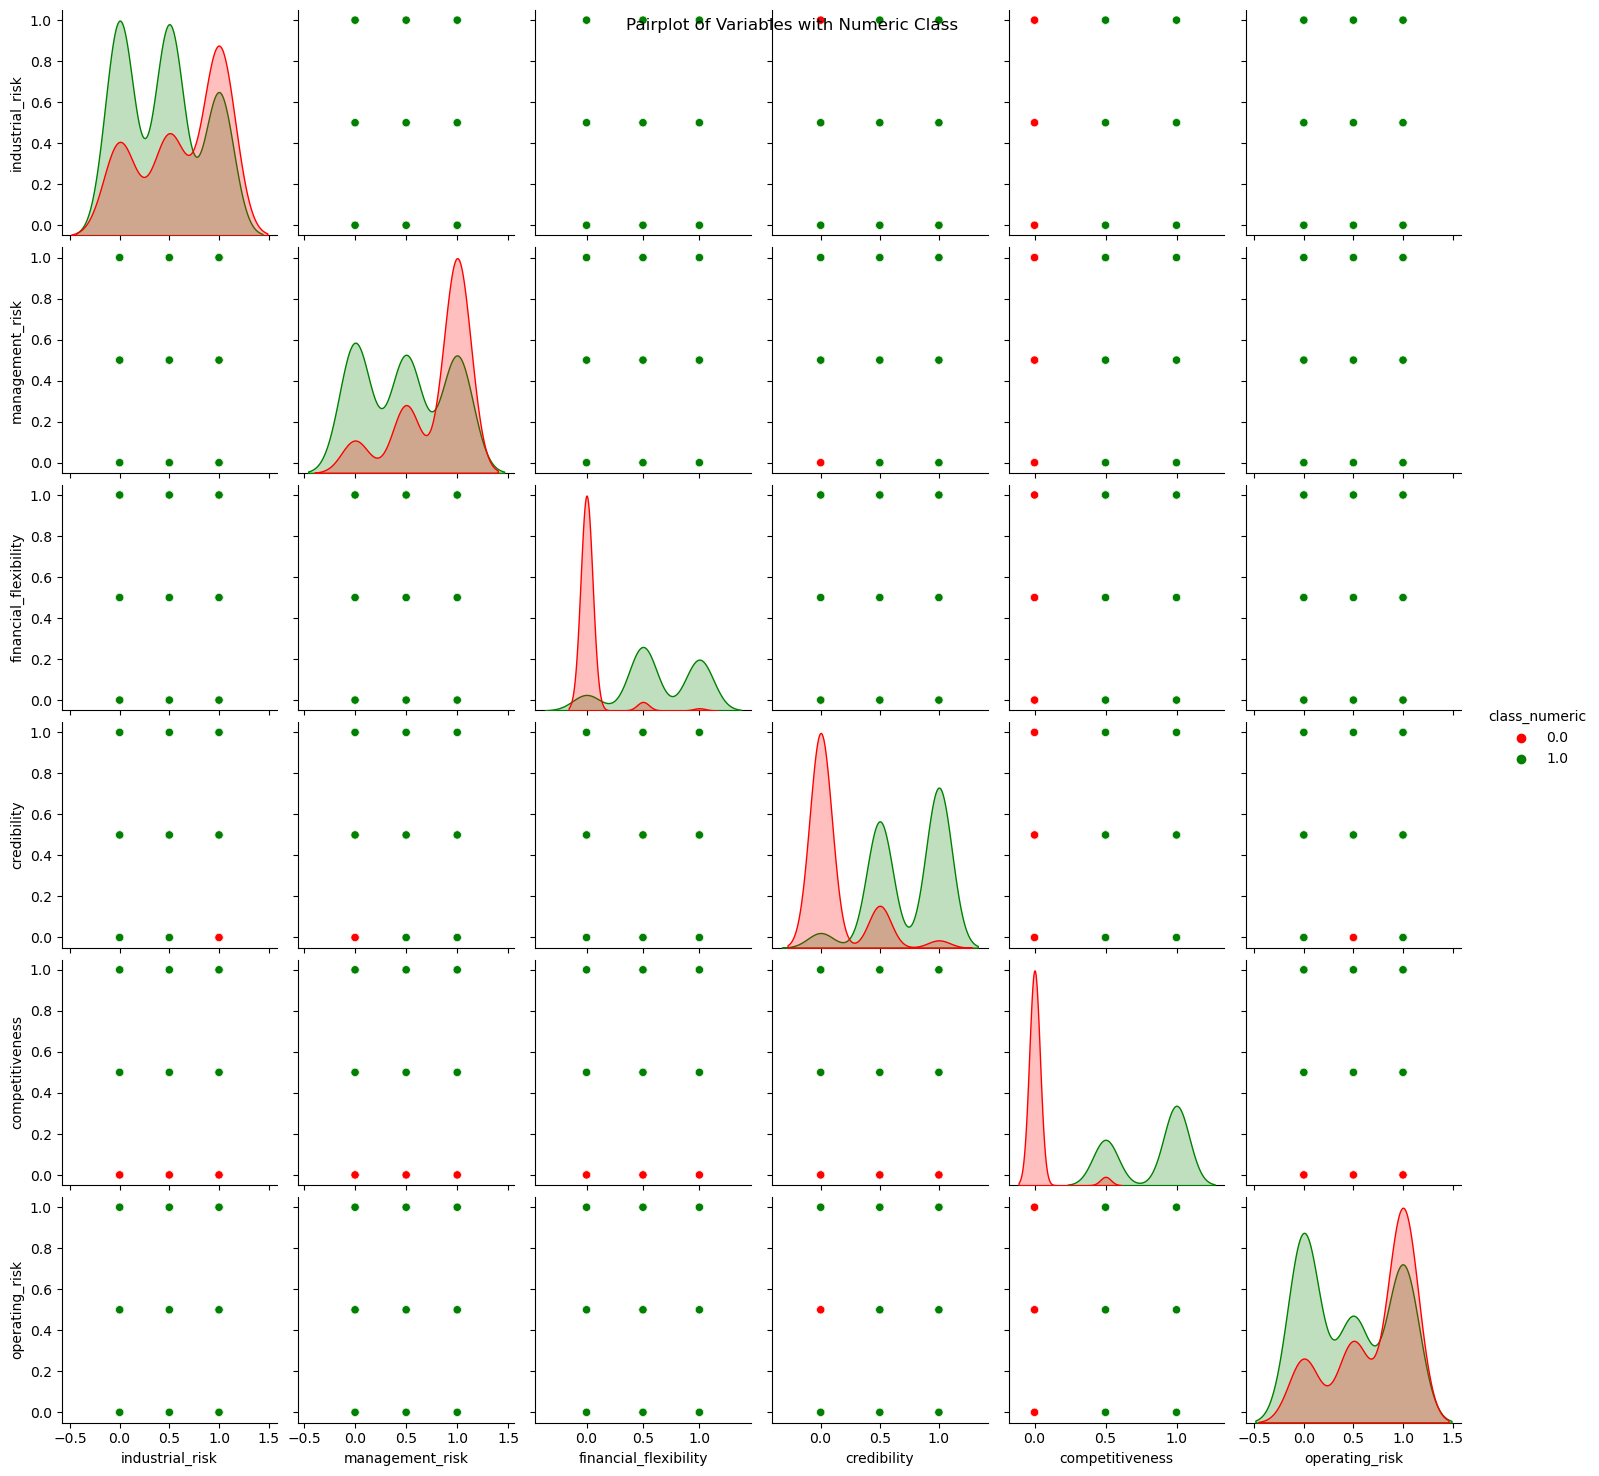

In [ ]:
# Pairplot for visualizing relationships between variables
sns.pairplot(train_df, hue='class_numeric', palette={0: 'red', 1: 'green'})
plt.suptitle('Pairplot of Variables with Numeric Class')
plt.show()

In [ ]:
train_df

,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class_numeric
0,0.5,1.0,0.0,0.0,0.0,0.5,0.0
1,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.5,0.0,0.0,0.5,0.0,1.0,0.0
4,1.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...
245,0.0,1.0,1.0,1.0,1.0,1.0,1.0
246,1.0,1.0,0.5,1.0,1.0,0.0,1.0
247,0.0,1.0,1.0,0.5,0.5,0.0,1.0
248,1.0,0.0,0.5,1.0,0.5,0.0,1.0


In [ ]:
#correlation matrix to check the compatibility
correlation_matrix = train_df.corr()
correlation_matrix

,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class_numeric
industrial_risk,1.000000,0.255127,-0.162624,-0.014438,-0.257814,0.144507,-0.227823
management_risk,0.255127,1.000000,-0.254845,-0.303341,-0.306568,0.213874,-0.370838
financial_flexibility,-0.162624,-0.254845,1.000000,0.524951,0.686612,-0.116903,0.751020
credibility,-0.014438,-0.303341,0.524951,1.000000,0.675689,-0.288458,0.755909
competitiveness,-0.257814,-0.306568,0.686612,0.675689,1.000000,-0.211383,0.899452
operating_risk,0.144507,0.213874,-0.116903,-0.288458,-0.211383,1.000000,-0.279786
class_numeric,-0.227823,-0.370838,0.751020,0.755909,0.899452,-0.279786,1.000000


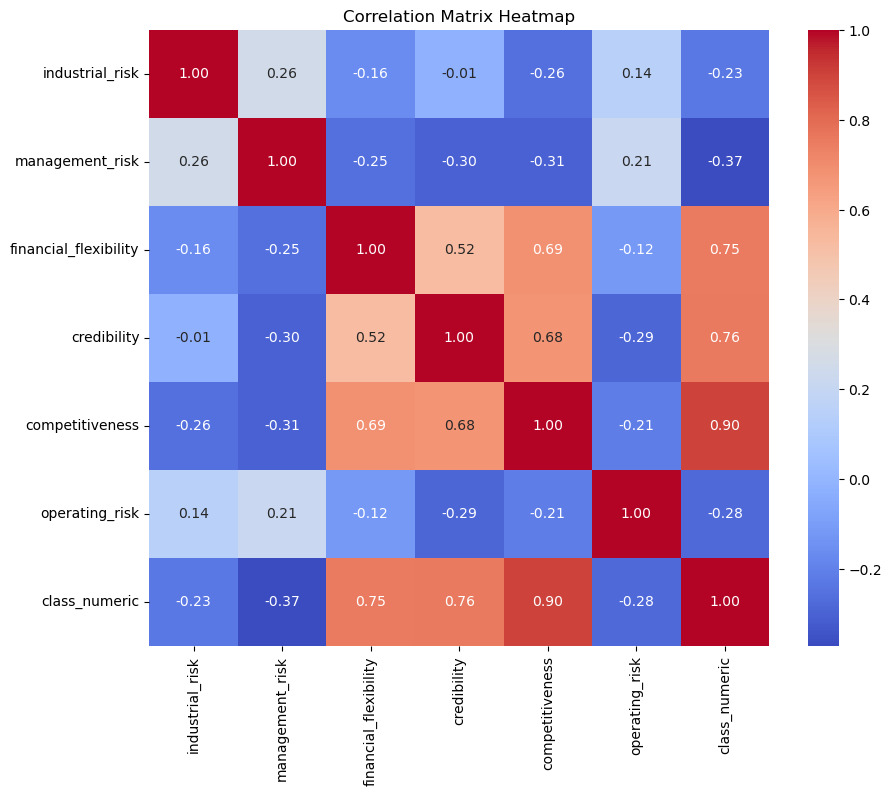

In [ ]:
# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

checking whether the dataset is balanced or unbalanced

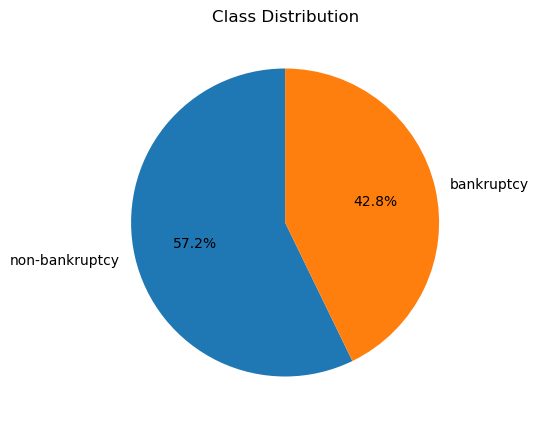

In [ ]:
plt.figure(figsize=(8, 5))
class_counts = df['class'].value_counts()
class_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Class Distribution')
plt.ylabel('')  
plt.show()

In [ ]:
imbalance_ratio = class_counts[0] / class_counts[1]  # Assuming binary classification
print(f'Imbalance Ratio: {imbalance_ratio}')

Imbalance Ratio: 1.3364485981308412


# Model Building

train and test split

In [ ]:
X = train_df.drop('class_numeric', axis=1)
y = train_df['class_numeric']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

logistic regression

In [ ]:
model = LogisticRegression()
# Train the model on the training data
model.fit(X_train, y_train)
# Make predictions on the test data
y_pred = model.predict(X_test)

In [ ]:
train_accuracy = accuracy_score(y_train, model.predict(X_train))
test_accuracy = accuracy_score(y_test, y_pred)
print("Trainning Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Trainning Accuracy: 0.995
Testing Accuracy: 1.0


In [ ]:
#Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

In [ ]:

print("Accuracy:", accuracy)
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", classification_rep)

Accuracy: 1.0
Confusion Matrix:
 [[21  0]
 [ 0 29]]
Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        21
         1.0       1.00      1.00      1.00        29

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



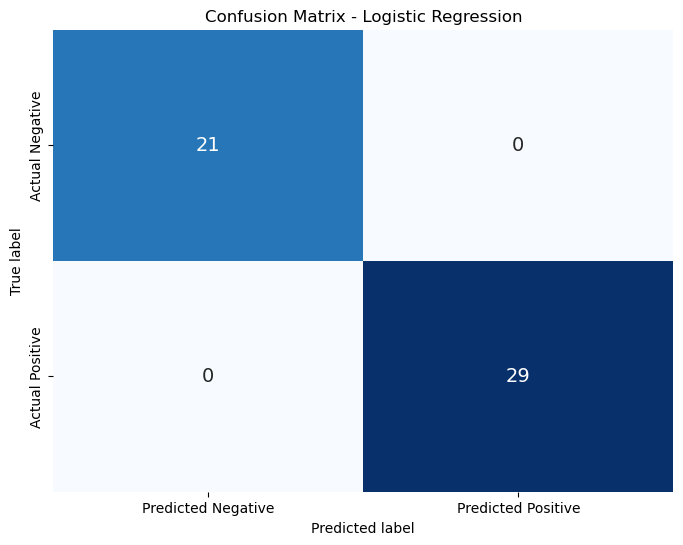

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='g', cbar=False, 
            annot_kws={"size": 14}, 
            xticklabels=['Predicted Negative', 'Predicted Positive'], 
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

random forest

In [ ]:
random_forest_model = RandomForestClassifier()
# Train the model on the training data
random_forest_model.fit(X_train, y_train)
# Make predictions on the test data
y_pred_rf = random_forest_model.predict(X_test)

In [ ]:
train_accuracy = accuracy_score(y_train, model.predict(X_train))
test_accuracy = accuracy_score(y_test, y_pred_rf)
print("Trainning Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Trainning Accuracy: 0.995
Testing Accuracy: 1.0


In [ ]:
#Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
conf_matrix = confusion_matrix(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

In [ ]:
print("Random Forest Accuracy:", accuracy_rf)
print("\nRandom Forest Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nRandom Forest Classification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 1.0

Random Forest Confusion Matrix:
 [[21  0]
 [ 0 29]]

Random Forest Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        21
         1.0       1.00      1.00      1.00        29

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



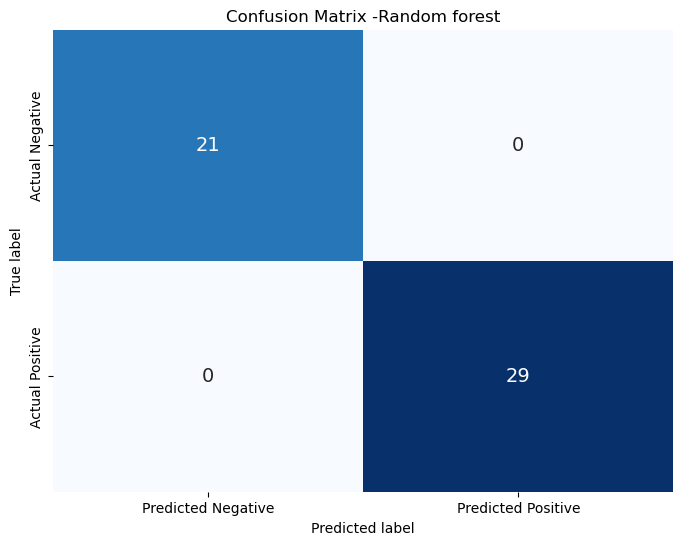

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='g', cbar=False, 
            annot_kws={"size": 14}, 
            xticklabels=['Predicted Negative', 'Predicted Positive'], 
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix -Random forest')
plt.show()

Support Vector Machine(SVC)

In [ ]:
svm_model = SVC(kernel='linear', C=1.0)
svm_model.fit(X_train, y_train)

SVC(kernel='linear')

In [ ]:
y_pred_svc = svm_model.predict(X_test)

In [ ]:
train_accuracy = accuracy_score(y_train, model.predict(X_train))
test_accuracy = accuracy_score(y_test, y_pred_svc)
print("Trainning Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Trainning Accuracy: 0.995
Testing Accuracy: 1.0


In [ ]:
accuracy = accuracy_score(y_test, y_pred_svc)
conf_matrix = confusion_matrix(y_test, y_pred_svc)
class_report = classification_report(y_test, y_pred_svc)

In [ ]:
print("Accuracy:", accuracy)
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", class_report)

Accuracy: 1.0

Confusion Matrix:
 [[21  0]
 [ 0 29]]

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        21
         1.0       1.00      1.00      1.00        29

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



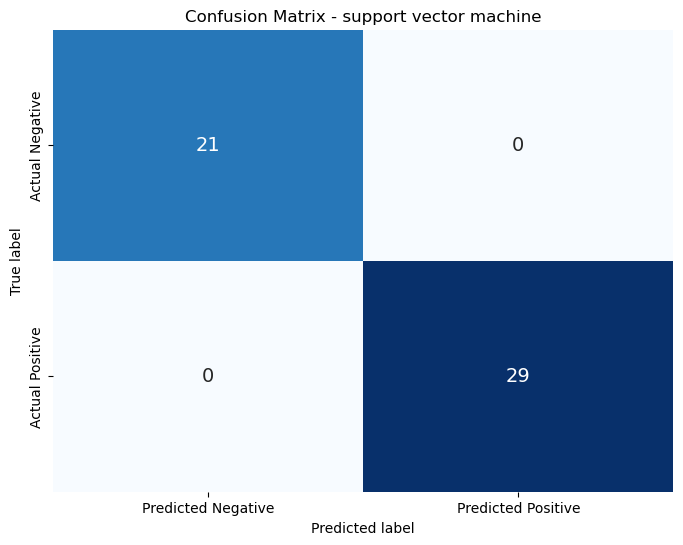

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='g', cbar=False, 
            annot_kws={"size": 14}, 
            xticklabels=['Predicted Negative', 'Predicted Positive'], 
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix - support vector machine')
plt.show()

KNN

In [ ]:
knn_model=KNeighborsClassifier(n_neighbors =7, p = 2, metric = 'euclidean')
knn_model.fit(X_train,y_train)
y_pred_knn=knn_model.predict(X_test)

In [ ]:
train_accuracy = accuracy_score(y_train, model.predict(X_train))
test_accuracy = accuracy_score(y_test, y_pred_knn)
print("Trainning Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Trainning Accuracy: 0.995
Testing Accuracy: 0.98


In [ ]:
accuracy_knn = accuracy_score(y_test, y_pred_knn)
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)
classification_rep_knn = classification_report(y_test, y_pred_knn)

In [ ]:
print("Accuracy:", accuracy_knn)
print("Confusion Matrix:\n", conf_matrix_knn)
print("Classification Report:\n", classification_rep_knn)

Accuracy: 0.98
Confusion Matrix:
 [[21  0]
 [ 1 28]]
Classification Report:
               precision    recall  f1-score   support

         0.0       0.95      1.00      0.98        21
         1.0       1.00      0.97      0.98        29

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50



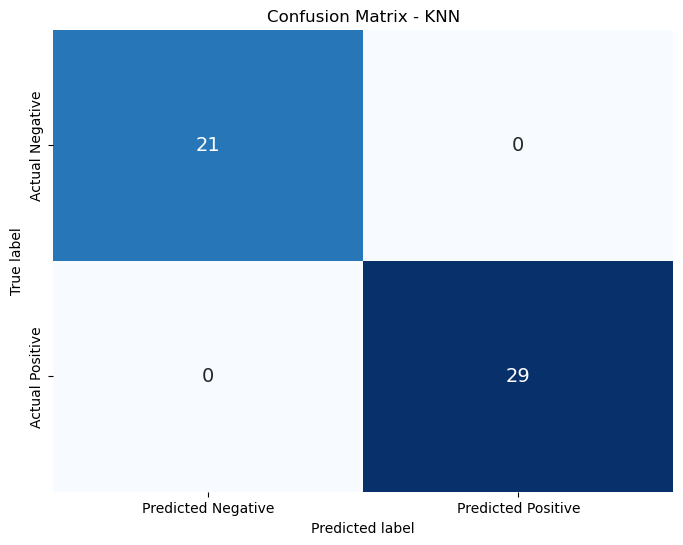

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='g', cbar=False, 
            annot_kws={"size": 14}, 
            xticklabels=['Predicted Negative', 'Predicted Positive'], 
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix - KNN')
plt.show()